In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet
from surprise import Reader, Dataset, SVD, accuracy
from surprise.model_selection import train_test_split

import warnings; warnings.simplefilter('ignore')

In [2]:
pd.set_option("display.max_columns",25)
md = pd. read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/movies_metadata.csv")
md.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
# Basic shape + types
display(md.shape)

(45466, 24)

In [4]:
display(md.dtypes)

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object

In [5]:
num_cols = ['budget','revenue','runtime','popularity','vote_average','vote_count']
for c in num_cols:
    md[c] = pd.to_numeric(md[c], errors='coerce')

In [6]:
# Missingness
missing = (md.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing.head(20))

belongs_to_collection    90.12
homepage                 82.88
tagline                  55.10
overview                  2.10
poster_path               0.85
runtime                   0.58
status                    0.19
release_date              0.19
imdb_id                   0.04
original_language         0.02
spoken_languages          0.01
title                     0.01
popularity                0.01
video                     0.01
vote_average              0.01
revenue                   0.01
vote_count                0.01
production_companies      0.01
production_countries      0.01
budget                    0.01
dtype: float64

In [7]:
cols_to_drop = missing[missing > 80].index
md.drop(columns=cols_to_drop, inplace=True)

In [8]:
md['tagline'] = md['tagline'].fillna('')

In [9]:
num_cols = md.select_dtypes(include='number').columns
md[num_cols] = md[num_cols].fillna(md[num_cols].median())

In [10]:
cat_cols = md.select_dtypes(include='object').columns
md[cat_cols] = md[cat_cols].fillna(md[cat_cols].mode().iloc[0])

In [11]:
md['release_date'] = pd.to_datetime(md['release_date'], errors='coerce')
md['release_date'] = md['release_date'].fillna(md['release_date'].mode()[0])

In [12]:
(md.isna().mean() * 100).round(2).sort_values(ascending=False).head(24)

adult                   0.0
budget                  0.0
vote_average            0.0
video                   0.0
title                   0.0
tagline                 0.0
status                  0.0
spoken_languages        0.0
runtime                 0.0
revenue                 0.0
release_date            0.0
production_countries    0.0
production_companies    0.0
poster_path             0.0
popularity              0.0
overview                0.0
original_title          0.0
original_language       0.0
imdb_id                 0.0
id                      0.0
genres                  0.0
vote_count              0.0
dtype: float64

In [13]:
md[num_cols].describe()

,budget,popularity,revenue,runtime,vote_average,vote_count
count,4.546600e+04,45466.000000,4.546600e+04,45466.000000,45466.000000,45466.000000
mean,4.224300e+06,2.921242,1.120787e+07,94.133242,5.618258,109.884155
std,1.742359e+07,6.005053,6.432813e+07,38.296618,1.924094,491.279294
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,0.386080,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,1.127685,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,3.678343,0.000000e+00,107.000000,6.800000,34.000000
max,3.800000e+08,547.488298,2.787965e+09,1256.000000,10.000000,14075.000000


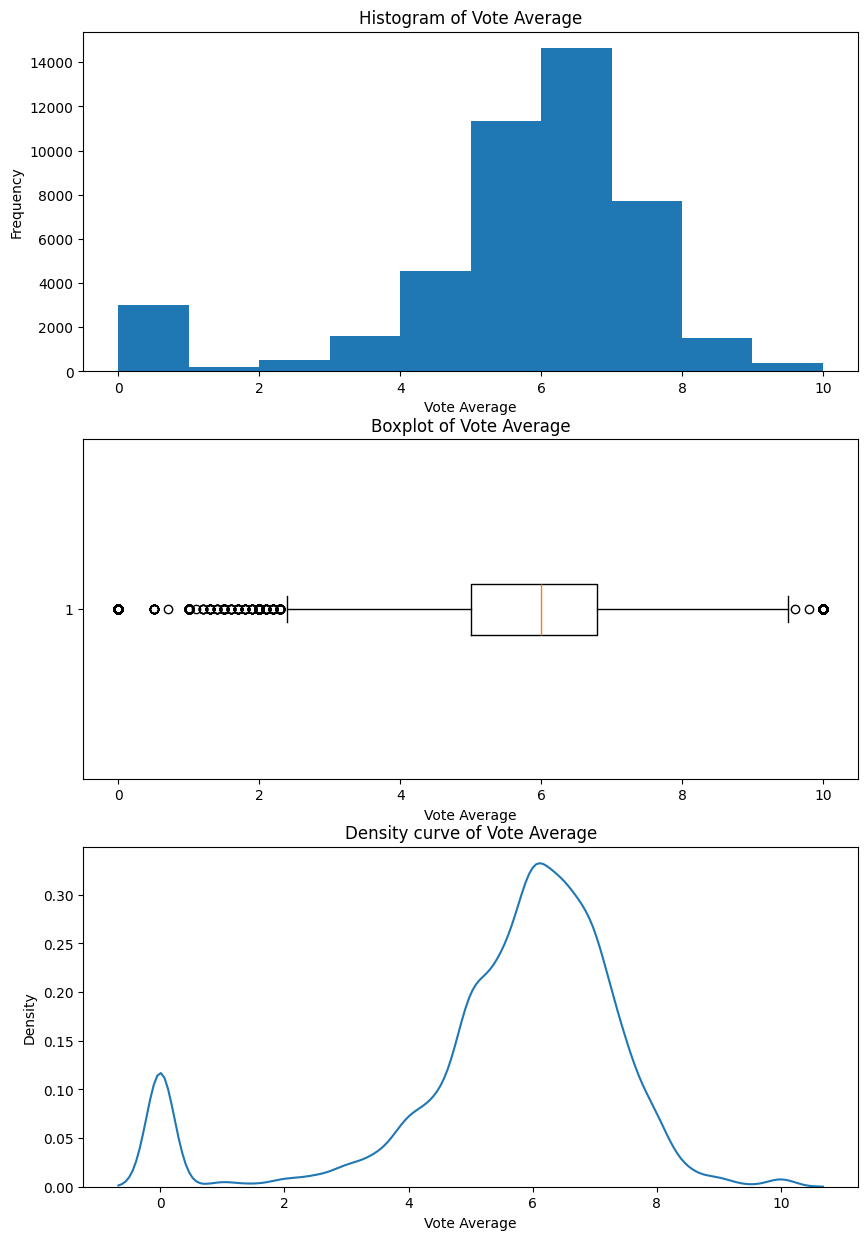

In [14]:
plt.figure(figsize=(10,15))

plt.subplot(3,1,1)
plt.hist(md['vote_average'])
plt.title('Histogram of Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')

plt.subplot(3,1,2)
plt.boxplot(md['vote_average'],vert=False)
plt.title('Boxplot of Vote Average')
plt.xlabel('Vote Average')

plt.subplot(3,1,3)
sns.kdeplot(md['vote_average'])
plt.title('Density curve of Vote Average')
plt.xlabel('Vote Average')

plt.show()


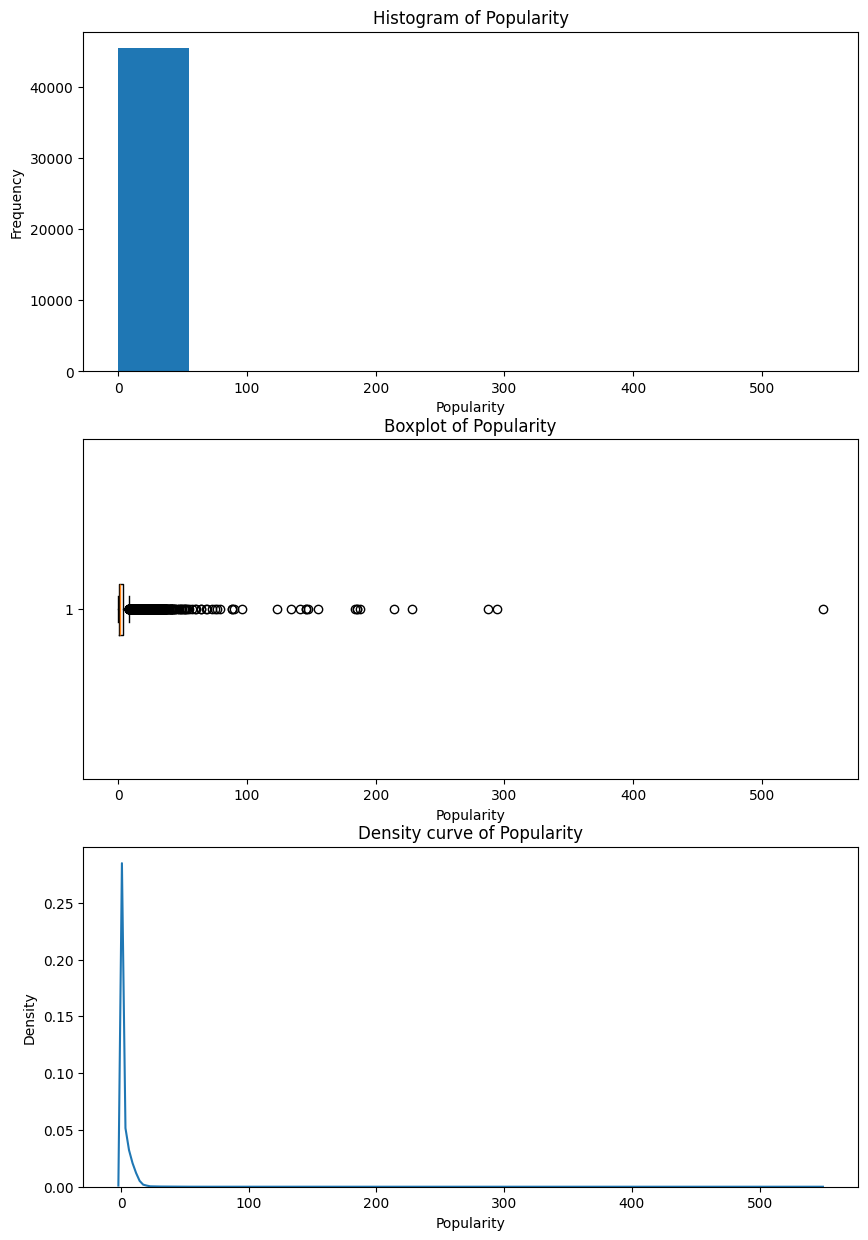

In [15]:
plt.figure(figsize=(10,15))

plt.subplot(3,1,1)
plt.hist(md['popularity'])
plt.title('Histogram of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')

plt.subplot(3,1,2)
plt.boxplot(md['popularity'],vert=False)
plt.title('Boxplot of Popularity')
plt.xlabel('Popularity')

plt.subplot(3,1,3)
sns.kdeplot(md['popularity'])
plt.title('Density curve of Popularity')
plt.xlabel('Popularity')

plt.show()


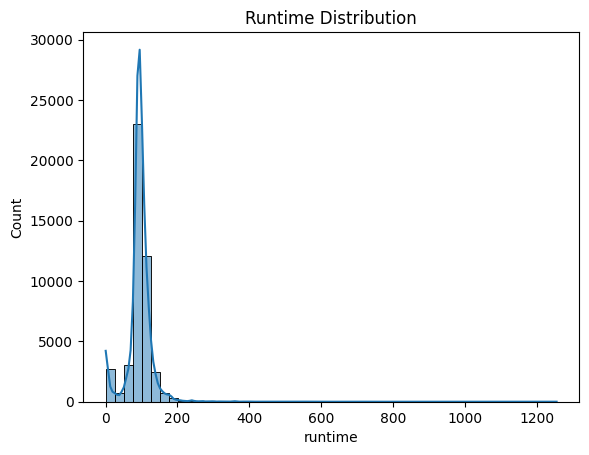

In [16]:
sns.histplot(md['runtime'], bins=50, kde=True)
plt.title("Runtime Distribution")
plt.show()

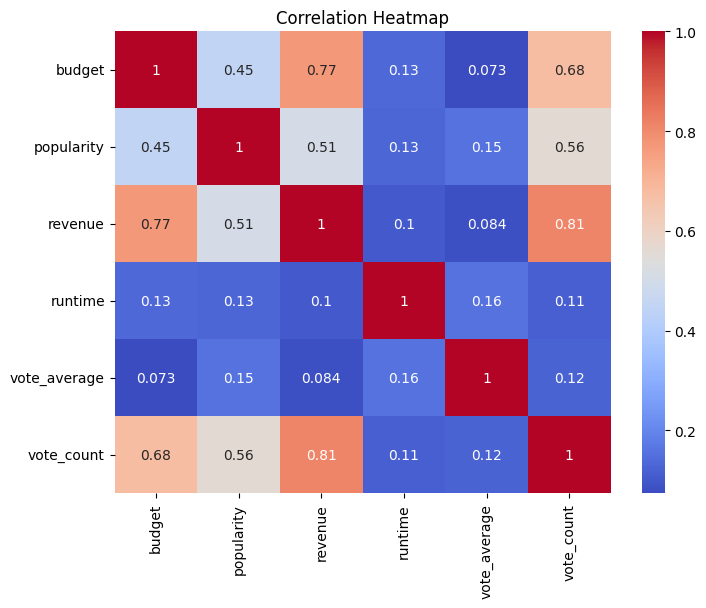

In [17]:
corr = md[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

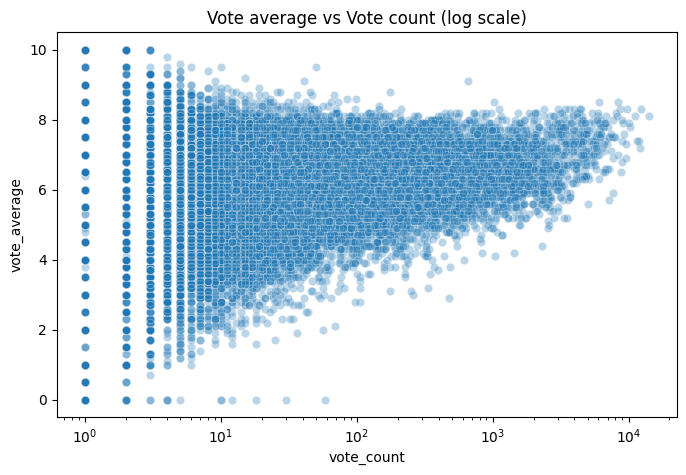

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=md, x='vote_count', y='vote_average', alpha=0.3)
plt.xscale('log')
plt.title("Vote average vs Vote count (log scale)")
plt.show()

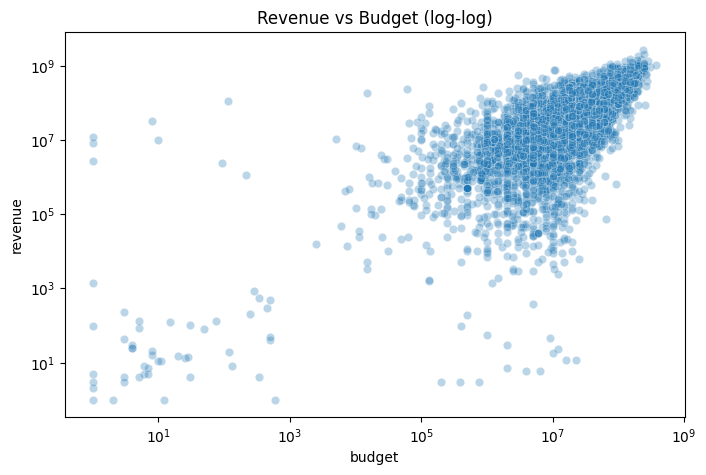

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=md, x='budget', y='revenue', alpha=0.3)
plt.xscale('log'); plt.yscale('log')
plt.title("Revenue vs Budget (log-log)")
plt.show()

In [20]:
md['year'] = pd.to_datetime(md['release_date'], errors='coerce').apply(lambda x: str(x).split('-')[0] if x != np.nan else np.nan)

Average rating by release year

In [21]:
md.groupby('year')['vote_average'].mean().dropna().tail(20)

year
2000    5.453105
2001    5.507630
2002    5.565856
2003    5.635374
2004    5.692036
2005    5.596622
2006    5.600787
2007    5.645909
2008    5.404734
2009    5.600567
2010    5.712458
2011    5.645651
2012    5.644251
2013    5.757650
2014    5.646657
2015    5.764882
2016    5.823628
2017    5.864662
2018    0.000000
2020    0.000000
Name: vote_average, dtype: float64

Movies count by year

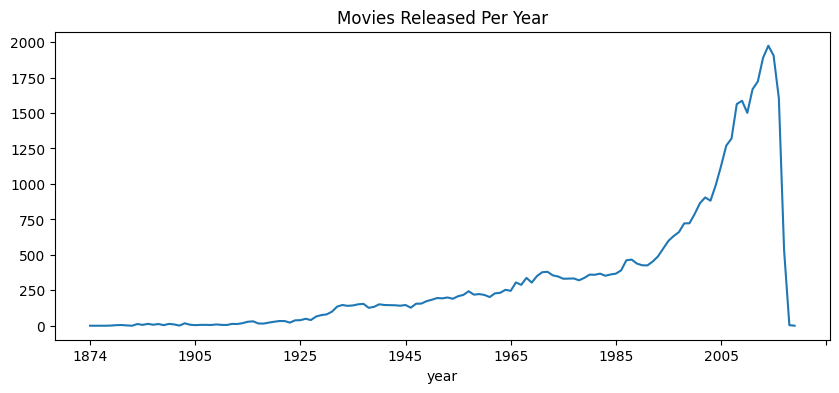

In [22]:
md['year'].value_counts().sort_index().plot(figsize=(10,4))
plt.title("Movies Released Per Year")
plt.show()

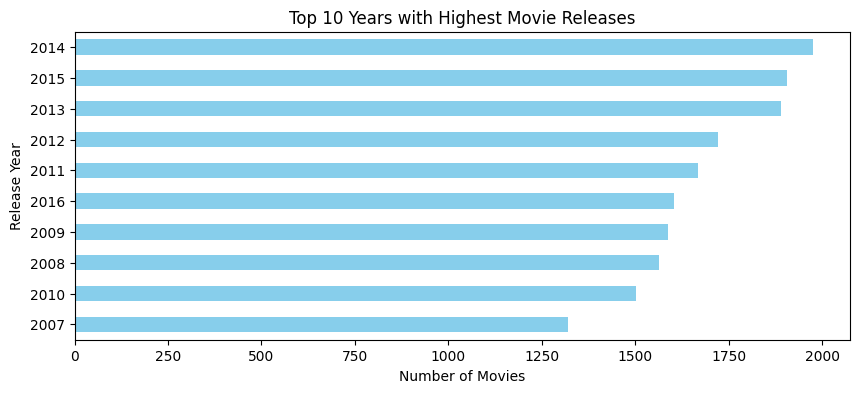

In [23]:
year_counts = md['year'].value_counts().sort_index()
top_years = year_counts.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4))

top_years.sort_values().plot(
    kind='barh',
    color='skyblue'
)

plt.title("Top 10 Years with Highest Movie Releases")
plt.xlabel("Number of Movies")
plt.ylabel("Release Year")

plt.show()

In [24]:
#md['genres'] = md['genres'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
md['genres'] = md['genres'].apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[29], line 6
      4 credits['id'] = credits['id'].astype(int)
      5 keywords['id'] = keywords['id'].astype(int)
----> 6 md['id'] = md['id'].astype('int')
      8 md = md.merge(credits, on='id')
      9 md = md.merge(keywords, on='id')

File ~/Documents/Data_Analytics/env/lib/python3.10/site-packages/pandas/core/generic.py:6665, in NDFrame.astype(self, dtype, copy, errors)
   6659     results = [
   6660         ser.astype(dtype, copy=copy, errors=errors) for _, ser in self.items()
   6661     ]
   6663 else:
   6664     # else, only a single dtype is given
-> 6665     new_data = self._mgr.astype(dtype=dtype, copy=copy, errors=errors)
   6666     res = self._constructor_from_mgr(new_data, axes=new_data.axes)
   6667     return res.__finalize__(self, method="astype")

File ~/Documents/Data_Analytics/env/lib/python3.10/site-packages/pandas/core/internals/managers.py:449, in BaseBlockManager.astype(self, dtype, copy, errors)
    446 elif using_copy_on_write():
    447     copy = False
--> 449 return self.apply(
    450     "astype",
    451     dtype=dtype,
...
    132     # Explicit copy, or required since NumPy can't view from / to object.
--> 133     return arr.astype(dtype, copy=True)
    135 return arr.astype(dtype, copy=copy)

ValueError: invalid literal for int() with base 10: '1997-08-20'

In [25]:
md = md.drop([19730, 29503, 35587], errors='ignore')

In [26]:
credits  = pd.read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/credits.csv")
keywords = pd.read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/keywords.csv")

credits['id'] = credits['id'].astype(int)
keywords['id'] = keywords['id'].astype(int)
md['id'] = md['id'].astype('int')

md = md.merge(credits, on='id')
md = md.merge(keywords, on='id')

In [27]:
links_small = pd.read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/links_small.csv")
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')

smd = md[md['id'].isin(links_small)]

In [28]:
smd['cast'] = smd['cast'].apply(literal_eval)
smd['crew'] = smd['crew'].apply(literal_eval)
smd['keywords'] = smd['keywords'].apply(literal_eval)

def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name'].lower().replace(" ", "")
    return ""

smd['director'] = smd['crew'].apply(get_director)

smd['cast'] = smd['cast'].apply(lambda x: [i['name'].lower().replace(" ", "") for i in x[:3]])
smd['keywords'] = smd['keywords'].apply(lambda x: [i['name'].lower().replace(" ", "") for i in x])

In [29]:
smd['soup'] = (
    smd['keywords'] +
    smd['cast'] +
    smd['genres'] +
    smd['director'].apply(lambda x: [x, x, x])
)

smd['soup'] = smd['soup'].apply(lambda x: ' '.join(x))

In [30]:
count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(smd['soup'])

cosine_sim = cosine_similarity(count_matrix, count_matrix)

smd = smd.reset_index(drop=True)
indices = pd.Series(smd.index, index=smd['title'])

In [31]:
ratings = pd.read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/ratings_small.csv")

reader = Reader()
data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']], reader
)



In [32]:
from surprise.model_selection import KFold
kf = KFold(n_splits=5, random_state=42, shuffle=True)

for trainset, testset in kf.split(data):
    # use trainset and testset here
    pass

from surprise.model_selection import cross_validate

svd = SVD()
cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9033  0.8922  0.8994  0.8919  0.8985  0.8971  0.0044  
MAE (testset)     0.6985  0.6869  0.6937  0.6865  0.6883  0.6908  0.0046  
Fit time          0.34    0.37    0.31    0.38    0.35    0.35    0.02    
Test time         0.11    0.03    0.03    0.10    0.03    0.06    0.04    


{'test_rmse': array([0.90332661, 0.89219719, 0.899429  , 0.89192515, 0.89847639]),
 'test_mae': array([0.69848281, 0.68687765, 0.69365727, 0.68647184, 0.68830871]),
 'fit_time': (0.3392188549041748,
  0.36521291732788086,
  0.31244492530822754,
  0.3769032955169678,
  0.353320837020874),
 'test_time': (0.11022782325744629,
  0.03084421157836914,
  0.0326838493347168,
  0.09704709053039551,
  0.03270673751831055)}

In [33]:
trainset = data.build_full_trainset()

svd.fit(trainset)

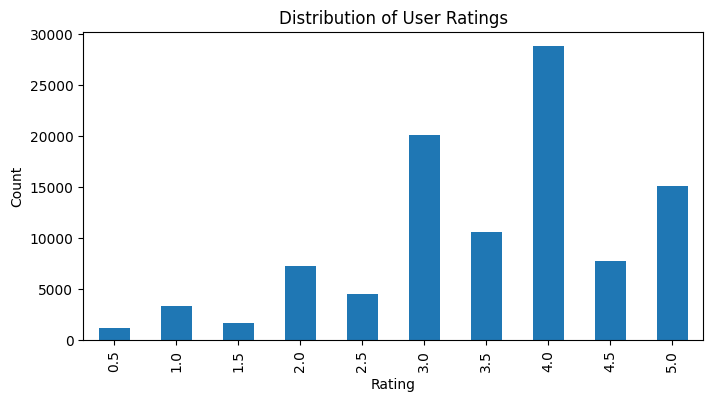

In [34]:
plt.figure(figsize=(8,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

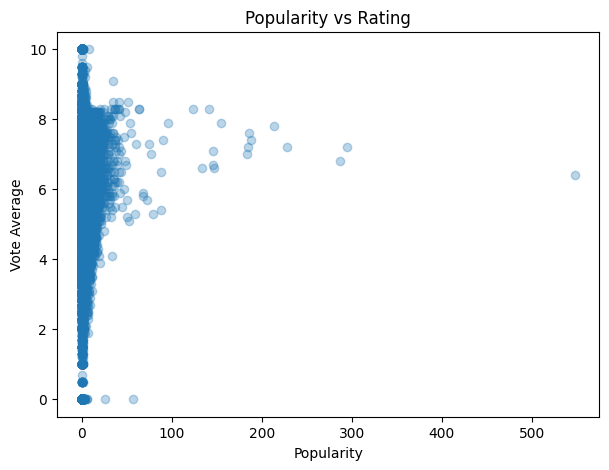

In [35]:
plt.figure(figsize=(7,5))
plt.scatter(md['popularity'], md['vote_average'], alpha=0.3)
plt.xlabel("Popularity")
plt.ylabel("Vote Average")
plt.title("Popularity vs Rating")
plt.show()

In [36]:
from collections import Counter

genre_counts = Counter(
    g for genres in md['genres'] for g in genres
)

genre_df = pd.DataFrame(
    genre_counts.items(),
    columns=['Genre','Count']
).sort_values('Count', ascending=False)

genre_df.head(10)

,Genre,Count
6,Drama,20809
1,Comedy,13467
9,Thriller,7794
5,Romance,6923
7,Action,6730
10,Horror,4762
8,Crime,4387
17,Documentary,4050
3,Adventure,3587
12,Science Fiction,3140


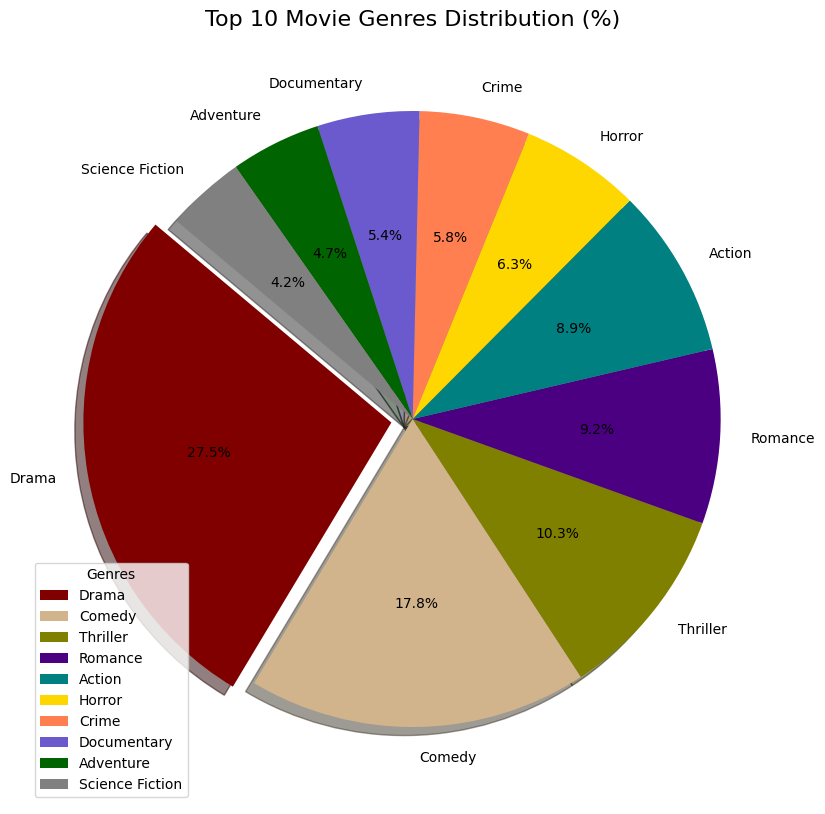

In [37]:
plt.figure(figsize=(15,10))

plt.pie(
    genre_df['Count'][:10],
    labels=genre_df['Genre'][:10],
    autopct='%.1f%%',
    startangle=140,
    explode=[0.07] + [0]*9,   # highlight top genre
    shadow=True,
    colors=('maroon','tan','olive','indigo','teal','gold','coral','slateblue','darkgreen','gray')
)

plt.title('Top 10 Movie Genres Distribution (%)', fontsize=16)
plt.legend(title='Genres', loc='best')
plt.show()


In [38]:
idmap = pd.read_csv("/Users/sujith/Documents/Data_Analytics/archive (2)/links_small.csv")[['movieId','tmdbId']]
idmap['tmdbId'] = pd.to_numeric(idmap['tmdbId'], errors='coerce')

idmap.columns = ['movieId', 'id']
idmap = idmap.merge(smd[['title','id']], on='id')
idmap = idmap.set_index('title')

indices_map = idmap.set_index('id')


In [39]:
def hybrid(userId, title, top_n=10):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:26]

    movie_indices = [i[0] for i in sim_scores]

    movies = smd.iloc[movie_indices][
        ['title', 'vote_count', 'vote_average', 'year', 'id']
    ].copy()

    movies['movieId'] = movies['id'].apply(
        lambda x: indices_map.loc[x]['movieId']
    )

    movies['est'] = movies['movieId'].apply(
        lambda x: svd.predict(userId, x).est
    )

    movies = movies.sort_values('est', ascending=False)

    return movies.head(top_n)


In [40]:
hybrid(userId=1, title= "Avengers: Age of Ultron")

,title,vote_count,vote_average,year,id,movieId,est
7929,The Avengers,12000.0,7.4,2012,24428,89745,3.164168
7853,X-Men: First Class,5252.0,7.1,2011,49538,87232,3.068797
6220,Serenity,1287.0,7.4,2005,16320,34405,3.057419
7211,Dr. Horrible's Sing-Along Blog,236.0,7.8,2008,14301,66934,3.054794
7883,Captain America: The First Avenger,7174.0,6.6,2011,1771,88140,3.034975
8590,Captain America: The Winter Soldier,5881.0,7.6,2014,100402,110102,2.952272
8837,Ant-Man,6029.0,7.0,2015,102899,122900,2.917835
6973,Iron Man,8951.0,7.4,2008,1726,59315,2.828098
7825,Thor,6678.0,6.6,2011,10195,86332,2.761801
7008,The Incredible Hulk,3086.0,6.1,2008,1724,60040,2.745103


In [41]:
import pickle

# Save trained SVD model
with open("artifacts/svd.pkl", "wb") as f:
    pickle.dump(svd, f)

# Save cosine similarity
with open("artifacts/cosine_sim.pkl", "wb") as f:
    pickle.dump(cosine_sim, f)

# Save smd dataframe
with open("artifacts/smd.pkl", "wb") as f:
    pickle.dump(smd, f)

# Save indices
with open("artifacts/indices.pkl", "wb") as f:
    pickle.dump(indices, f)

# Save id mappings
with open("artifacts/indices_map.pkl", "wb") as f:
    pickle.dump(indices_map, f)

print("✅ All artifacts saved successfully")


✅ All artifacts saved successfully
